# Define Imports

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
# fix python path if working locally
from utils import fix_pythonpath_if_working_locally

fix_pythonpath_if_working_locally()

# import warnings

# warnings.filterwarnings("ignore", category=FutureWarning)

# Define And split dataset

In [3]:
from darts.datasets import ElectricityConsumptionZurichDataset

<Axes: xlabel='Timestamp'>

/usr/local/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/usr/local/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


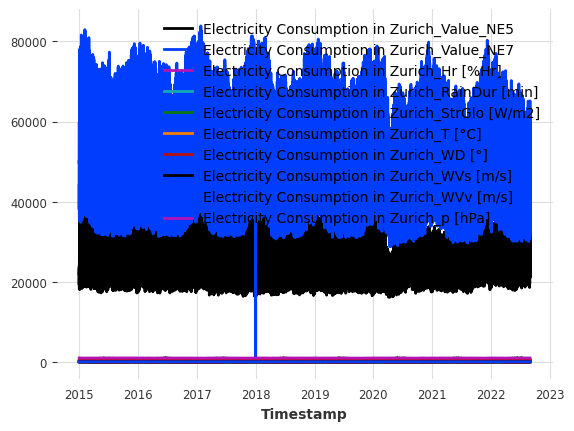

In [4]:
series = ElectricityConsumptionZurichDataset().load()
series.plot(label="Electricity Consumption in Zurich")

In [5]:
from darts.datasets import ElectricityConsumptionZurichDataset
from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler
import pandas as pd

# 1. load your series
series = ElectricityConsumptionZurichDataset().load()

# get just 5% of the data for demonstration purposes
# TODO REMOVE FOR REAL IMPLEMENTATION
series = series[:int(len(series) * 0.05)]

# 2. define split percentages
TRAIN_PERCENT = 0.6   # 60% for training
VAL_PERCENT = 0.2     # 20% for validation  
TEST_PERCENT = 0.2    # 20% for testing

# 3. calculate split points based on total length
total_len = len(series)
train_size = int(total_len * TRAIN_PERCENT)
val_size = int(total_len * VAL_PERCENT)

# 4. get split timestamps
train_end = series.time_index[train_size - 1]
val_end = series.time_index[train_size + val_size - 1]

# 5. perform the splits
train, remainder = series.split_after(train_end)
val, test = remainder.split_after(val_end)

print(f"Total series length: {total_len}")
print(f"Train size: {len(train)} ({len(train)/total_len*100:.1f}%)")
print(f"Val size: {len(val)} ({len(val)/total_len*100:.1f}%)")
print(f"Test size: {len(test)} ({len(test)/total_len*100:.1f}%)")
print(f"train: {train.time_index[0]} → {train.time_index[-1]}")
print(f"val:   {val.time_index[0]} → {val.time_index[-1]}")
print(f"test:  {test.time_index[0]} → {test.time_index[-1]}")

# scale the series
scaler = Scaler()
train_scaled = scaler.fit_transform(train)
val_scaled = scaler.transform(val)
test_scaled = scaler.transform(test)


Total series length: 13435
Train size: 8061 (60.0%)
Val size: 2687 (20.0%)
Test size: 2687 (20.0%)
train: 2015-01-01 00:00:00 → 2015-03-25 23:00:00
val:   2015-03-25 23:15:00 → 2015-04-22 22:45:00
test:  2015-04-22 23:00:00 → 2015-05-20 22:30:00


## Adapt the dataset to covariates and scale

In [6]:
from darts.utils.timeseries_generation import datetime_attribute_timeseries
import holidays
import numpy as np
from darts import TimeSeries

# Create raw covariates
cov_month = datetime_attribute_timeseries(series, "month", one_hot=False)
cov_day   = datetime_attribute_timeseries(series, "day", one_hot=False)
# we want the order of the data because of transformers
cov_linear = TimeSeries.from_times_and_values(
    times=series.time_index,
    values=np.arange(len(series)).reshape(-1, 1),
    columns=["linear_increase"]
)

# Holiday flag (Zurich)
import holidays
# Create holiday set once
zh_holidays = holidays.Switzerland(prov="ZH")
# Check all dates against that single holiday set
is_holiday = np.array([1 if date in zh_holidays else 0 for date in series.time_index])
holiday_series = TimeSeries.from_times_and_values(series.time_index, is_holiday.reshape(-1,1), columns=["is_holiday"])

# Stack all together
covariates = cov_month.stack(cov_day).stack(cov_linear).stack(holiday_series)

# Split and scale
cov_train = covariates.slice(train.start_time(), train.end_time())
cov_val   = covariates.slice(val.start_time(), val.end_time())
cov_test  = covariates.slice(test.start_time(), test.end_time())

scaler_cov = Scaler()
cov_train_scaled = scaler_cov.fit_transform(cov_train)
cov_val_scaled   = scaler_cov.transform(cov_val)
cov_test_scaled  = scaler_cov.transform(cov_test)

VAL_LEN = len(val)

print("Covariate columns:", covariates.columns)
print("Covariates shape:", covariates.width, "features over", len(covariates), "time steps")

# scale whole dataset - better for evaulation
series_scaled = scaler.transform(series)
covariates_scaled = scaler_cov.transform(covariates)


Covariate columns: Index(['month', 'day', 'linear_increase', 'is_holiday'], dtype='object', name='component')
Covariates shape: 4 features over 13435 time steps


# Define Hyperparameters finetuning 

In [7]:
# From some reason the model has to be initialized like this
# when we use darts.model import TFT it has a pytroch error, so we need to avoid it with this import
from darts.models.forecasting.tft_model import TFTModel
import optuna
import torch
from pytorch_lightning.callbacks import EarlyStopping, Callback
from optuna.integration import PyTorchLightningPruningCallback
from darts.metrics import smape
from darts.utils.likelihood_models import QuantileRegression

# Patch pruning callback (due to compatibility issue)
class PatchedPruningCallback(PyTorchLightningPruningCallback, Callback):
    pass


Support for Torch based models not available. To enable them, install "darts", "u8darts[torch]" or "u8darts[all]" (with pip); or "u8darts-torch" or "u8darts-all" (with conda).


In [14]:
def eval_model(model, n, actual_series, num_samples, val_series, **predict_kwargs):
    """
    Predict with `model.predict(n=n, **predict_kwargs)`,
    plot actual vs. quantiles, and return SMAPE.
    """
    # run the prediction
    pred = model.predict(n=n, num_samples=num_samples, **predict_kwargs)

    # plot
    # plt.figure(figsize=figsize)
    # actual_series[:pred.end_time()].plot(label="actual")
    # pred.plot(low_quantile=lowest_q, high_quantile=highest_q, label=label_q_outer)
    # pred.plot(low_quantile=low_q,    high_quantile=high_q,    label=label_q_inner)
    # plt.title(f"SMAPE: {smape(val_series, pred):.2f}%")
    # plt.legend()
    # plt.show()

    # return the SMAPE so we can use it as our objective value
    return smape(val_series, pred)

In [19]:
NR_EPOCHS = 1
def objective(trial):
    # TODO objectives are different when we use SSM model!
    in_len = trial.suggest_int("input_chunk_length", 12, 36)
    out_len = trial.suggest_int("output_chunk_length", 6, 24)
    hidden_size = trial.suggest_categorical("hidden_size", [32, 64, 128])
    dropout = trial.suggest_float("dropout", 0.0, 0.3)
    heads = trial.suggest_categorical("num_attention_heads", [1, 2, 4])
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)

    # callbacks
    callbacks = [
        PatchedPruningCallback(trial, monitor="val_loss"),
        EarlyStopping("val_loss", patience=3, verbose=False)
    ]

    model = TFTModel(
        input_chunk_length=in_len,
        output_chunk_length=out_len,
        hidden_size=hidden_size,
        lstm_layers=1,
        num_attention_heads=heads,
        dropout=dropout,
        batch_size=32,
        n_epochs=NR_EPOCHS,
        likelihood=QuantileRegression(),
        optimizer_kwargs={"lr": lr},
        pl_trainer_kwargs={"callbacks": callbacks},
        random_state=42,
        force_reset=True,
        save_checkpoints=True,
        model_name="optuna_tft",
    )

    # 1) extend the end of your series to include the encoder window
    val_extended = series_scaled[-(VAL_LEN + in_len):]

    # 2) get covariates over exactly that same span
    cov_val_ext = covariates_scaled.slice(
        val_extended.start_time(),
        val_extended.end_time()
    )

    model.fit(
        series=train_scaled,
        val_series=val_extended,
        future_covariates=cov_train_scaled,
        val_future_covariates=cov_val_ext,
        verbose=True,
    )


    # reload best checkpoint...
    model = TFTModel.load_from_checkpoint("optuna_tft")

    # 3) for prediction, use covariates over the validation period
    return eval_model(
        model=model,
        n=VAL_LEN,
        actual_series=series_scaled,
        val_series=val_scaled,
        num_samples=300,         # pass number of samples -> can also be a hyperparam?
        future_covariates=covariates_scaled # we can pass everything the model just process it correctly
    )


In [20]:
def print_callback(study, trial):
    print(f"Trial {trial.number}: Value: {trial.value}, Params: {trial.params}")
    print(f"Best so far: {study.best_value}, Params: {study.best_trial.params}")

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30, callbacks=[print_callback])


[I 2025-06-19 11:22:30,099] A new study created in memory with name: no-name-fb08f260-1688-4592-af2b-b066d27b9532
Original TFT Model initialized... why?
Original _TFT_Module initialized... why?
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 0      | train
4  | encoder_vsn                       | _VariableSelectionNetwork        | 47.5 K | train
5  | decoder_vsn                       | _VariableS

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Training: |          | 0/? [00:00<?, ?it/s]


Detected KeyboardInterrupt, attempting graceful shutdown ...
[W 2025-06-19 11:25:25,301] Trial 1 failed with parameters: {'input_chunk_length': 35, 'output_chunk_length': 23, 'hidden_size': 128, 'dropout': 0.05082893158401908, 'num_attention_heads': 2, 'lr': 0.001332813381891035} because of the following error: NameError("name 'exit' is not defined").
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/site-packages/pytorch_lightning/trainer/call.py", line 48, in _call_and_handle_interrupt
    return trainer_fn(*args, **kwargs)
  File "/usr/local/lib/python3.10/site-packages/pytorch_lightning/trainer/trainer.py", line 599, in _fit_impl
    self._run(model, ckpt_path=ckpt_path)
  File "/usr/local/lib/python3.10/site-packages/pytorch_lightning/trainer/trainer.py", line 1012, in _run
    results = self._run_stage()
  File "/usr/local/lib/python3.10/site-packages/pytorch_lightning/trainer/trainer.py", line 1056, in _run_stage
    self.fit_loop.run()
  File "/usr/local/lib

NameError: name 'exit' is not defined